# Example for bssunfold package with FISTA and Hybrid GMRES solvers

- Two advanced iterative algorithms: `unfold_fista()` and `unfold_hybrid_gmres()`

- **FISTA** (Fast Iterative Shrinkage-Thresholding Algorithm): An accelerated proximal gradient method achieving O(1/k²) convergence rate. Supports L1 regularization (sparsity), Total Variation (TV) regularization, and box constraints.

- **Hybrid GMRES**: Combines GMRES iteration with Tikhonov regularization on projected problems. Automatically selects regularization parameter using GCV (Generalized Cross Validation) or discrepancy principle.

Both methods are based on implementations from IRtools by Silvia Gazzola et al.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bssunfold import Detector, RF_LANL
from bssunfold.utils.plotting import plot_comparison

det = Detector(RF_LANL)

## Get effective readings for spectra

In [2]:
reference_spectrum = pd.read_csv('../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv')
readings = det.get_effective_readings_for_spectra(reference_spectrum[['E_MeV','ISO_ref_Cf252']])
readings

{'3in': 0.33993480011525595,
 '4in': 1.1540267733387468,
 '5in': 1.6949642349997989,
 '6in': 2.414902989013657,
 '8in': 2.506955384471506,
 '9in': 2.5925178363346078,
 '12in': 1.7633955277542266,
 '18in': 0.509007911100528,
 '9inPb': 2.654290882145632,
 '12inPb': 1.9428831470830863,
 '18inPb': 0.5878222748066373}

## FISTA Unfolding

The FISTA algorithm is well-suited for problems where:
- You want sparsity in the solution (L1 regularization)
- You need smooth solutions (Total Variation regularization)
- You have box constraints on the solution

Key parameters:
- `l1_penalty`: Controls sparsity (higher = more zeros in solution)
- `tv_penalty`: Controls smoothness (higher = smoother solution)
- `regularization`: Tikhonov regularization parameter
- `max_iterations`: Maximum number of iterations
- `tolerance`: Convergence tolerance

In [3]:
# Unfold using FISTA with default parameters
result_fista = det.unfold_fista(
    readings=readings,
    max_iterations=500,
    tolerance=1e-8,
    regularization=0.01,  # Small Tikhonov regularization
    l1_penalty=0.0,       # No L1 penalty
    tv_penalty=0.0,       # No TV penalty
    nonnegativity=True,   # Enforce non-negative spectrum
    random_state=42
)

print(f"FISTA converged in {result_fista['iterations']} iterations")
print(f"Final residual norm: {result_fista['final_residual_norm']:.6f}")

FISTA converged in 500 iterations
Final residual norm: 0.007029


In [10]:
result_fista

{'energy': array([1.00000000e-09, 1.58489319e-09, 2.51188643e-09, 3.98107171e-09,
        6.30957344e-09, 1.00000000e-08, 1.58489319e-08, 2.51188643e-08,
        3.98107171e-08, 6.30957344e-08, 1.00000000e-07, 1.58489319e-07,
        2.51188643e-07, 3.98107171e-07, 6.30957344e-07, 1.00000000e-06,
        1.58489319e-06, 2.51188643e-06, 3.98107171e-06, 6.30957344e-06,
        1.00000000e-05, 1.58489319e-05, 2.51188643e-05, 3.98107171e-05,
        6.30957344e-05, 1.00000000e-04, 1.58489319e-04, 2.51188643e-04,
        3.98107171e-04, 6.30957344e-04, 1.00000000e-03, 1.58489319e-03,
        2.51188643e-03, 3.98107171e-03, 6.30957344e-03, 1.00000000e-02,
        1.58489319e-02, 2.51188643e-02, 3.98107171e-02, 6.30957344e-02,
        1.00000000e-01, 1.58489319e-01, 2.51188643e-01, 3.98107171e-01,
        6.30957344e-01, 1.00000000e+00, 1.58489319e+00, 2.51188643e+00,
        3.98107171e+00, 6.30957344e+00, 1.00000000e+01, 1.58489319e+01,
        2.51188643e+01, 3.98107171e+01, 6.30957344e+01

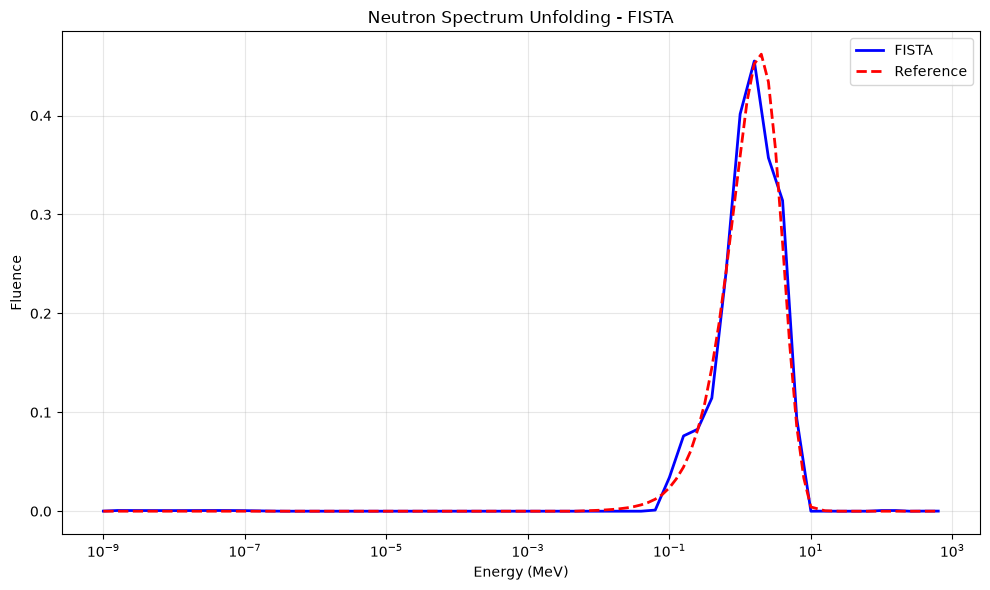

In [11]:
# Plot FISTA result
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(result_fista['energy'], result_fista['spectrum'], 'b-', linewidth=2, label='FISTA')
ax.semilogx(reference_spectrum['E_MeV'], reference_spectrum['ISO_ref_Cf252'], 'r--', linewidth=2, label='Reference')
ax.set_xlabel('Energy (MeV)')
ax.set_ylabel('Fluence')
ax.set_title('Neutron Spectrum Unfolding - FISTA')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### FISTA with L1 Regularization (Sparsity)

L1 regularization promotes sparse solutions, which can be useful when the true spectrum is expected to have few dominant energy peaks.

In [5]:
# FISTA with L1 regularization
result_fista_l1 = det.unfold_fista(
    readings=readings,
    max_iterations=500,
    tolerance=1e-8,
    regularization=0.0,
    l1_penalty=0.1,       # L1 penalty for sparsity
    tv_penalty=0.0,
    nonnegativity=True,
    random_state=42
)

print(f"FISTA with L1 converged in {result_fista_l1['iterations']} iterations")
print(f"Number of non-zero elements: {np.sum(result_fista_l1['spectrum'] > 1e-10)}")

FISTA with L1 converged in 500 iterations
Number of non-zero elements: 9


## Hybrid GMRES Unfolding

The Hybrid GMRES method:
- Builds a Krylov subspace using Golub-Kahan bidiagonalization
- Applies Tikhonov regularization to the projected problem at each iteration
- Automatically selects the regularization parameter using GCV or discrepancy principle
- Stops when the GCV minimum stabilizes or maximum iterations reached

Key parameters:
- `max_iterations`: Maximum Krylov dimension
- `regularization_method`: 'gcv', 'modgcv', or 'discrep'
- `noise_level`: For discrepancy principle (if using 'discrep')

In [12]:
# Unfold using Hybrid GMRES with GCV
result_gmres = det.unfold_hybrid_gmres(
    readings=readings,
    max_iterations=100,
    regularization_method='gcv',  # Automatic selection via GCV
    regularization=0.0,           # Will be auto-selected
    reorthogonalization=True,     # Full reorthogonalization for stability
    random_state=42
)

print(f"Hybrid GMRES stopped at iteration {result_gmres['iterations']}")
print(f"Final residual norm: {result_gmres['residual_norm']:.6f}")
print(f"Regularization parameters selected: {len(result_gmres['regularization_parameters'])} values")

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1 and the array at index 1 has size 2

NameError: name 'result_gmres' is not defined

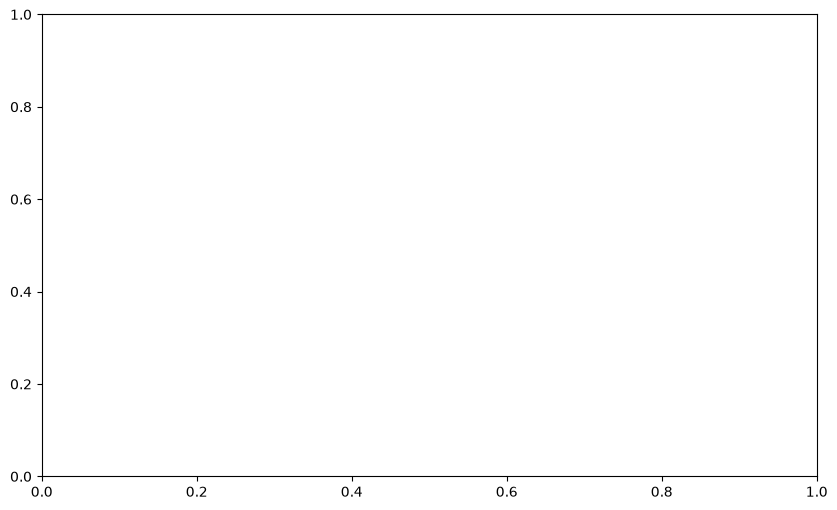

In [7]:
# Plot Hybrid GMRES result
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(result_gmres['energy'], result_gmres['spectrum'], 'g-', linewidth=2, label='Hybrid GMRES')
ax.semilogy(reference_spectrum['E_MeV'], reference_spectrum['ISO_ref_Cf252'], 'r--', linewidth=2, label='Reference')
ax.set_xlabel('Energy (MeV)')
ax.set_ylabel('Fluence')
ax.set_title('Neutron Spectrum Unfolding - Hybrid GMRES')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Comparison of Methods

Let's compare all unfolding results side by side.

NameError: name 'result_gmres' is not defined

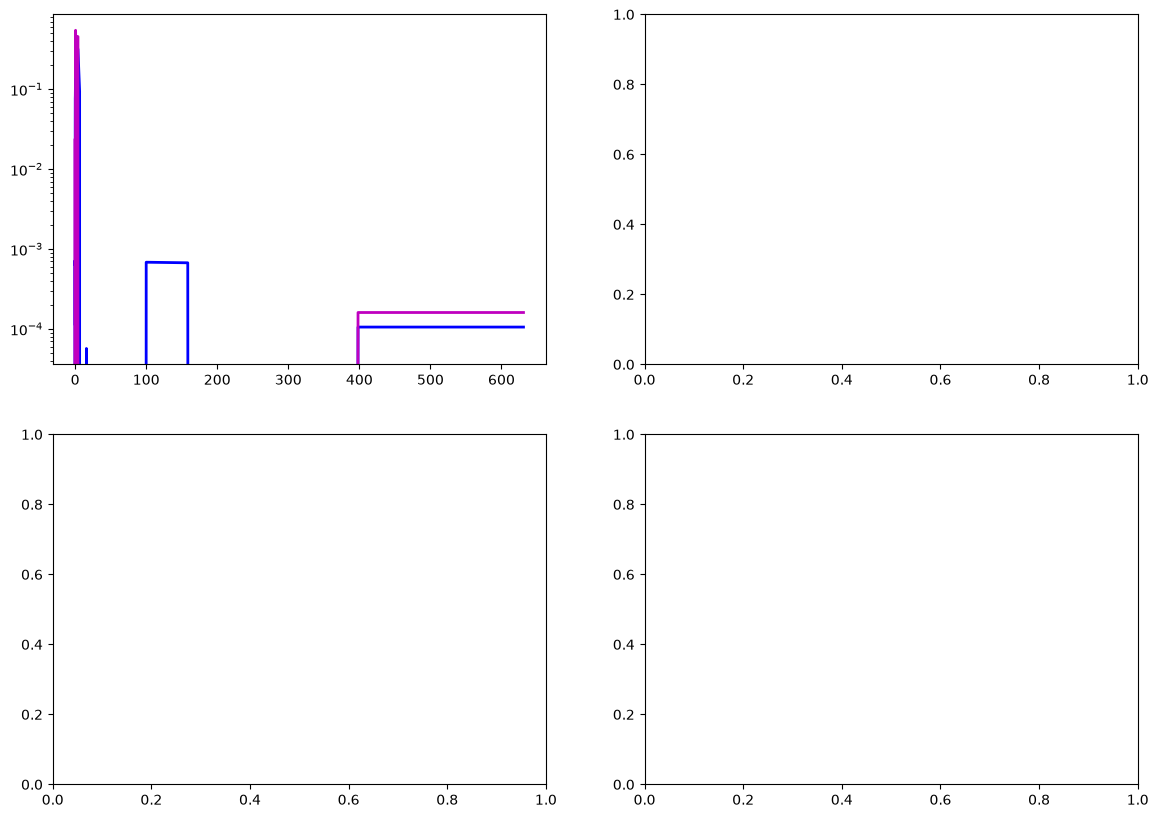

In [8]:
# Compare all methods
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Spectrum comparison
ax = axes[0, 0]
ax.semilogy(result_fista['energy'], result_fista['spectrum'], 'b-', linewidth=2, label='FISTA')
ax.semilogy(result_fista_l1['energy'], result_fista_l1['spectrum'], 'm-', linewidth=2, label='FISTA+L1')
ax.semilogy(result_gmres['energy'], result_gmres['spectrum'], 'g-', linewidth=2, label='Hybrid GMRES')
ax.semilogy(reference_spectrum['E_MeV'], reference_spectrum['ISO_ref_Cf252'], 'r--', linewidth=2, label='Reference')
ax.set_xlabel('Energy (MeV)')
ax.set_ylabel('Fluence')
ax.set_title('Spectrum Comparison')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Residual comparison
ax = axes[0, 1]
methods = ['FISTA', 'FISTA+L1', 'Hybrid GMRES']
residuals = [
    result_fista['residual_norm'],
    result_fista_l1['residual_norm'],
    result_gmres['residual_norm']
]
bars = ax.bar(methods, residuals, color=['blue', 'magenta', 'green'])
ax.set_ylabel('Residual Norm')
ax.set_title('Final Residual Norm Comparison')
for bar, val in zip(bars, residuals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', va='bottom')

# FISTA convergence history
ax = axes[1, 0]
if 'objective_values' in result_fista:
    ax.plot(result_fista['objective_values'], 'b-', linewidth=2, label='FISTA objective')
ax.set_xlabel('Iteration')
ax.set_ylabel('Objective Value')
ax.set_title('FISTA Convergence History')
ax.legend()
ax.grid(True, alpha=0.3)

# GMRES regularization parameters
ax = axes[1, 1]
if 'regularization_parameters' in result_gmres:
    reg_params = result_gmres['regularization_parameters']
    ax.semilogy(range(len(reg_params)), reg_params, 'g-', linewidth=2, label='Lambda (GCV)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Regularization Parameter')
ax.set_title('Hybrid GMRES - Auto-selected Lambda')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Dose Rate Comparison

Compare dose rates calculated from unfolded spectra.

In [9]:
# Calculate reference dose rates
ref_doserates = det.calculate_dose_rates_for_spectrum(reference_spectrum[['E_MeV','ISO_ref_Cf252']])

print("Dose Rate Comparison (pSv cm²):")
print(f"{'Method':<15} {'H*(10)':<12} {'Hp(10)':<12} {'E':<12}")
print("-" * 51)
print(f"{'Reference':<15} {ref_doserates['h_star_10']:<12.2f} {ref_doserates['hp_10']:<12.2f} {ref_doserates['e']:<12.2f}")
print(f"{'FISTA':<15} {result_fista['doserates']['h_star_10']:<12.2f} {result_fista['doserates']['hp_10']:<12.2f} {result_fista['doserates']['e']:<12.2f}")
print(f"{'FISTA+L1':<15} {result_fista_l1['doserates']['h_star_10']:<12.2f} {result_fista_l1['doserates']['hp_10']:<12.2f} {result_fista_l1['doserates']['e']:<12.2f}")
print(f"{'Hybrid GMRES':<15} {result_gmres['doserates']['h_star_10']:<12.2f} {result_gmres['doserates']['hp_10']:<12.2f} {result_gmres['doserates']['e']:<12.2f}")

AttributeError: 'Detector' object has no attribute 'calculate_dose_rates_for_spectrum'

## Summary

**FISTA Advantages:**
- Fast convergence (O(1/k²))
- Flexible regularization (L1, TV, Tikhonov)
- Handles box constraints naturally
- Good for sparse or piecewise-smooth solutions

**Hybrid GMRES Advantages:**
- Automatic regularization parameter selection
- No need to tune hyperparameters manually
- Well-suited for ill-posed problems
- Built-in stopping criterion via GCV

**When to use each:**
- Use **FISTA** when you have specific regularization requirements (sparsity, smoothness) or constraints
- Use **Hybrid GMRES** when you want automatic parameter tuning and don't have strong prior knowledge about regularization strength